In [ ]:
!pip install opencv-python

In [ ]:
import cv2
import os

In [11]:
# Define paths
train_video_path = "/content/Avenue_Dataset/training_videos"
test_video_path = "/content/Avenue_Dataset/testing_videos"
train_frame_path = "/content/Avenue_Dataset/frames/train"
test_frame_path = "/content/Avenue_Dataset/frames/test"

In [ ]:
# Create directories
os.makedirs(train_frame_path, exist_ok=True)
os.makedirs(test_frame_path, exist_ok=True)

In [ ]:
def extract_frames(video_folder, output_folder, frame_interval=10):
    """
    Extracts frames from videos at a given interval and saves them.

    Args:
        video_folder (str): Path to folder containing videos.
        output_folder (str): Path to save extracted frames.
        frame_interval (int): Save every nth frame (default=10).
    """
    for video_file in os.listdir(video_folder):
        if video_file.endswith(".mp4") or video_file.endswith(".avi"):
            video_path = os.path.join(video_folder, video_file)
            cap = cv2.VideoCapture(video_path)
            count = 0
            frame_id = 0

            while cap.isOpened():
                ret, frame = cap.read()
                if not ret:
                    break

                if count % frame_interval == 0:
                    frame_filename = os.path.join(output_folder, f"{video_file}_frame_{frame_id}.jpg")
                    cv2.imwrite(frame_filename, frame)
                    frame_id += 1

                count += 1

            cap.release()
            print(f"Frames extracted from {video_file}")

    print(f"Frames saved in {output_folder}")

In [ ]:
# Extract frames from training and testing videos
extract_frames(train_video_path, train_frame_path)
extract_frames(test_video_path, test_frame_path)

print("Frame extraction completed!")

Frames extracted from 04.avi
Frames extracted from 01.avi
Frames extracted from 05.avi
Frames extracted from 14.avi
Frames extracted from 06.avi
Frames extracted from 12.avi
Frames extracted from 03.avi
Frames extracted from 08.avi
Frames extracted from 09.avi
Frames extracted from 16.avi
Frames extracted from 15.avi
Frames extracted from 07.avi
Frames extracted from 10.avi
Frames extracted from 13.avi
Frames extracted from 02.avi
Frames extracted from 11.avi
Frames saved in /content/Avenue_Dataset/frames/train
Frames extracted from 04.avi
Frames extracted from 01.avi
Frames extracted from 05.avi
Frames extracted from 14.avi
Frames extracted from 06.avi
Frames extracted from 12.avi
Frames extracted from 03.avi
Frames extracted from 08.avi
Frames extracted from 09.avi
Frames extracted from 18.avi
Frames extracted from 16.avi
Frames extracted from 15.avi
Frames extracted from 07.avi
Frames extracted from 10.avi
Frames extracted from 13.avi
Frames extracted from 17.avi
Frames extracted fr

In [3]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 977.1/977.1 kB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 94.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 79.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [4]:
from ultralytics import YOLO
import cv2
import os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# Load pre-trained YOLOv8 model (for auto-annotation)
model = YOLO("yolov8n.pt")

In [ ]:
# Define paths
frames_dir = "/content/Avenue_Dataset/frames"
labels_dir = "/content/Avenue_Dataset/labels"

In [ ]:
# Create label folders
train_labels_path = os.path.join(labels_dir, "train")
test_labels_path = os.path.join(labels_dir, "test")
os.makedirs(train_labels_path, exist_ok=True)
os.makedirs(test_labels_path, exist_ok=True)


In [ ]:
def annotate_images(frame_folder, label_folder):
    """
    Runs YOLO inference on frames and saves detected objects in YOLO format.
    """
    for frame_file in os.listdir(frame_folder):
        if frame_file.endswith(".jpg"):
            frame_path = os.path.join(frame_folder, frame_file)
            image = cv2.imread(frame_path)

            # Run YOLO detection
            results = model(image)

            # Save labels in YOLO format
            label_file = os.path.join(label_folder, frame_file.replace(".jpg", ".txt"))
            with open(label_file, "w") as f:
                for r in results:
                    for box in r.boxes:
                        x_center, y_center, width, height = box.xywhn[0]  # Normalized coordinates
                        class_id = int(box.cls[0])  # Class ID

                        # Write YOLO format: class x_center y_center width height
                        f.write(f"{class_id} {x_center} {y_center} {width} {height}\n")

            print(f"Annotated: {frame_file}")

In [ ]:
# Annotate training and testing frames
annotate_images(os.path.join(frames_dir, "train"), train_labels_path)
annotate_images(os.path.join(frames_dir, "test"), test_labels_path)

print("Auto-annotation completed! 🚀")

Streaming output truncated to the last 5000 lines.
0: 384x640 5 persons, 2 handbags, 155.3ms
Speed: 4.4ms preprocess, 155.3ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)
Annotated: 06.avi_frame_7.jpg

0: 384x640 7 persons, 3 handbags, 152.9ms
Speed: 2.6ms preprocess, 152.9ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)
Annotated: 01.avi_frame_82.jpg

0: 384x640 9 persons, 160.1ms
Speed: 4.3ms preprocess, 160.1ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)
Annotated: 11.avi_frame_16.jpg

0: 384x640 12 persons, 151.9ms
Speed: 4.1ms preprocess, 151.9ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)
Annotated: 04.avi_frame_86.jpg

0: 384x640 3 persons, 170.1ms
Speed: 4.4ms preprocess, 170.1ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)
Annotated: 13.avi_frame_28.jpg

0: 384x640 1 person, 159.0ms
Speed: 4.5ms preprocess, 159.0ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640

In [ ]:
# Paths
frames_dir = "/content/Avenue_Dataset/frames/train"  # Change to "test" if needed
labels_dir = "/content/Avenue_Dataset/labels/train"

In [ ]:
# Class names (Using COCO dataset for now, but we can modify this based on detected classes)
CLASS_NAMES = ["person", "bicycle", "car", "motorcycle", "airplane", "bus", "train", "truck", "boat", "traffic light",
               "fire hydrant", "stop sign", "parking meter", "bench", "bird", "cat", "dog", "horse", "sheep", "cow"]

In [ ]:
import cv2
import os
from google.colab.patches import cv2_imshow

In [ ]:
def visualize_annotations(image_file):
    """Loads an image and its YOLO annotation, then displays the bounding boxes."""
    img_path = os.path.join(frames_dir, image_file)
    label_path = os.path.join(labels_dir, image_file.replace(".jpg", ".txt"))

    # Load image
    image = cv2.imread(img_path)
    h, w, _ = image.shape  # Image dimensions

    # Read annotation file
    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()
            class_id = int(parts[0])
            x_center, y_center, box_width, box_height = map(float, parts[1:])

            # Convert YOLO format (normalized) to pixel values
            x1 = int((x_center - box_width / 2) * w)
            y1 = int((y_center - box_height / 2) * h)
            x2 = int((x_center + box_width / 2) * w)
            y2 = int((y_center + box_height / 2) * h)

            # Draw bounding box
            cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
            label = CLASS_NAMES[class_id] if class_id < len(CLASS_NAMES) else f"Class {class_id}"
            cv2.putText(image, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    # Show image in Colab
    cv2_imshow(image)

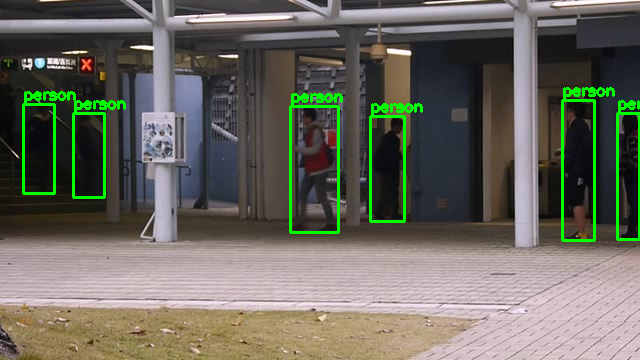

In [ ]:
# Check if frames_dir exists and contains files
if not os.path.exists(frames_dir) or not os.listdir(frames_dir):
    print(f"Error: The directory '{frames_dir}' is empty or does not exist.")
else:
    # Example: Pick any image from the training set
    sample_image = os.listdir(frames_dir)[0]  # Pick the first image
    visualize_annotations(sample_image)

In [ ]:
from ultralytics import YOLO

In [ ]:
import os

# Define paths
dataset_path = "/content/Avenue_Dataset"

# Rename frames to images
os.rename(os.path.join(dataset_path, "frames"), os.path.join(dataset_path, "images"))

print("Renamed 'frames/' to 'images/' successfully!")


Renamed 'frames/' to 'images/' successfully!


In [ ]:
# Train on Avenue Dataset
model.train(data="/content/Avenue_Dataset/dataset.yaml", epochs=20, imgsz=640, batch=8,lr0=0.001)

Ultralytics 8.3.99 🚀 Python-3.11.11 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/Avenue_Dataset/dataset.yaml, epochs=20, time=None, patience=100, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show

100%|██████████| 755k/755k [00:00<00:00, 14.6MB/s]


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

train: Scanning /content/Avenue_Dataset/labels/train... 1542 images, 0 backgrounds, 711 corrupt: 100%|██████████| 1542/1542 [00:00<00:00, 2187.03it/s]

train: WARNING ⚠️ /content/Avenue_Dataset/images/train/01.avi_frame_10.jpg: ignoring corrupt image/label: Label class 26 exceeds dataset class count 1. Possible class labels are 0-0
train: WARNING ⚠️ /content/Avenue_Dataset/images/train/01.avi_frame_11.jpg: ignoring corrupt image/label: Label class 26 exceeds dataset class count 1. Possible class labels are 0-0
train: WARNING ⚠️ /content/Avenue_Dataset/images/train/01.avi_frame_12.jpg: ignoring corrupt image/label: Label class 24 exceeds dataset class count 1. Possible class labels are 0-0
train: WARNING ⚠️ /content/Avenue_Dataset/images/train/01.avi_frame_134.jpg: ignoring corrupt image/label: Label class 26 exceeds dataset class count 1. Possible class labels are 0-0
train: WARNING ⚠️ /content/Avenue_Dataset/images/train/01.avi_frame_16.jpg: ignoring corrupt image/label: Label class 24 exceeds dataset class count 1. Possible class labels are 0-0
train: WARNING ⚠️ /content/Avenue_Dataset/images/train/01.avi_frame_17.jpg: ignoring corr

...

                   all        649       4181      0.952      0.886      0.957      0.816



20 epochs completed in 4.489 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train/weights/best.pt, 6.2MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.99 🚀 Python-3.11.11 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 41/41 [01:41<00:00,  2.47s/it]


                   all        649       4181      0.952      0.886      0.957      0.816
Speed: 1.5ms preprocess, 146.8ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to runs/detect/train


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7bbacf6c8510>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
import cv2
import os

# Paths
train_video_dir = "/content/Avenue_Dataset/training_videos"
output_dir = "/content/Avenue_Dataset/images/train"

os.makedirs(output_dir, exist_ok=True)

# Extract frames from training videos
for video_file in os.listdir(train_video_dir):
    video_path = os.path.join(train_video_dir, video_file)
    cap = cv2.VideoCapture(video_path)
    frame_count = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Save every 30th frame as a normal activity frame
        if frame_count % 30 == 0:
            frame_filename = f"{video_file}_frame{frame_count}.jpg"
            cv2.imwrite(os.path.join(output_dir, frame_filename), frame)

        frame_count += 1

    cap.release()

print("✅ Normal frames extracted successfully!")


✅ Normal frames extracted successfully!


In [ ]:
import os

# Paths
images_dir = "/content/Avenue_Dataset/images/train"
labels_dir = "/content/Avenue_Dataset/labels/train"

os.makedirs(labels_dir, exist_ok=True)

# Loop through all images
for image_file in os.listdir(images_dir):
    label_file = image_file.replace(".jpg", ".txt")
    label_path = os.path.join(labels_dir, label_file)

    # If label file doesn't exist, create an empty one
    if not os.path.exists(label_path):
        open(label_path, "w").close()  # Creates an empty file

print("✅ Empty label files created for normal images!")


✅ Empty label files created for normal images!


In [ ]:
from ultralytics import YOLO

# Load YOLO model
model = YOLO("yolov8n.pt")

# Train again with fixed dataset
model.train(data="/content/Avenue_Dataset/dataset.yaml", epochs=5, batch=8)


Ultralytics 8.3.99 🚀 Python-3.11.11 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/Avenue_Dataset/dataset.yaml, epochs=5, time=None, patience=100, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show

train: Scanning /content/Avenue_Dataset/labels/train... 2061 images, 519 backgrounds, 711 corrupt: 100%|██████████| 2061/2061 [00:01<00:00, 1185.71it/s]

train: WARNING ⚠️ /content/Avenue_Dataset/images/train/01.avi_frame_10.jpg: ignoring corrupt image/label: Label class 26 exceeds dataset class count 1. Possible class labels are 0-0
train: WARNING ⚠️ /content/Avenue_Dataset/images/train/01.avi_frame_11.jpg: ignoring corrupt image/label: Label class 26 exceeds dataset class count 1. Possible class labels are 0-0
train: WARNING ⚠️ /content/Avenue_Dataset/images/train/01.avi_frame_12.jpg: ignoring corrupt image/label: Label class 24 exceeds dataset class count 1. Possible class labels are 0-0
train: WARNING ⚠️ /content/Avenue_Dataset/images/train/01.avi_frame_134.jpg: ignoring corrupt image/label: Label class 26 exceeds dataset class count 1. Possible class labels are 0-0
train: WARNING ⚠️ /content/Avenue_Dataset/images/train/01.avi_frame_16.jpg: ignoring corrupt image/label: Label class 24 exceeds dataset class count 1. Possible class labels are 0-0
train: WARNING ⚠️ /content/Avenue_Dataset/images/train/01.avi_frame_17.jpg: ignoring corr

train: New cache created: /content/Avenue_Dataset/labels/train.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Scanning /content/Avenue_Dataset/labels/test.cache... 1543 images, 0 backgrounds, 894 corrupt: 100%|██████████| 1543/1543 [00:00<?, ?it/s]

...

                   all        649       4181      0.886      0.844      0.929      0.768



5 epochs completed in 1.764 hours.
Optimizer stripped from runs/detect/train2/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train2/weights/best.pt, 6.2MB

Validating runs/detect/train2/weights/best.pt...
Ultralytics 8.3.99 🚀 Python-3.11.11 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 41/41 [01:40<00:00,  2.46s/it]


                   all        649       4181      0.886      0.844      0.929      0.768
Speed: 1.5ms preprocess, 145.8ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to runs/detect/train2


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7bbaccc369d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [18]:
from ultralytics import YOLO

# Load trained model
model = YOLO("/content/runs/detect/train2/weights/best.pt")  # Ensure correct path

# Test video path
video_path = "/content/Avenue_Dataset/testing_videos/vidf.mp4"

# Run inference
results = model.predict(video_path, save=True, imgsz=640, conf=0.6, iou=0.5)

# 🔹 Iterate through all results
for result in results:
    if result.boxes is not None:
        # Convert tensor to numpy array
        boxes = result.boxes.xyxy.cpu().numpy()  # Bounding box coordinates
        confidences = result.boxes.conf.cpu().numpy()  # Confidence scores
        class_ids = result.boxes.cls.cpu().numpy()  # Class labels

        # 🔹 Apply filtering: Keep only boxes with confidence > 0.5
        filtered_indices = confidences > 0.5
        filtered_boxes = boxes[filtered_indices]
        filtered_confidences = confidences[filtered_indices]
        filtered_classes = class_ids[filtered_indices]

        # 🔹 Print the filtered results
        for box, conf, cls_id in zip(filtered_boxes, filtered_confidences, filtered_classes):
            print(f"Class: {cls_id}, Confidence: {conf:.2f}, BBox: {box}")




WARNING ⚠️ inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/1051) /content/Avenue_Dataset/testing_videos/vidf.mp4: 384x640 (no detections), 155.3ms
video 1/1 (frame 2/1051) /content/Avenue_Dataset/testing_videos/vidf.mp4: 384x640 (no detections), 124.9ms
video 1/1 (frame 3/1051) /content/Avenue_Dataset/testing_videos/vidf.mp4: 384x640 (no detections), 133.5ms
video 1/1 (frame 4/1051) /content/Avenue_Dataset/testing_videos/vidf.mp4: 384x640 (no detections), 135.4ms
video 1/1 (frame 5/1051) /co

In [ ]:
import os
print(os.listdir("/content/Avenue_Dataset/labels/train"))


['02.avi_frame_101.txt', '06.avi_frame_19.txt', '05.avi_frame_65.txt', '01.avi_frame_112.txt', '09.avi_frame_94.txt', '11.avi_frame_59.txt', '02.avi_frame_123.txt', '11.avi_frame_38.txt', '07.avi_frame_6.txt', '03.avi_frame_2.txt', '07.avi_frame780.txt', '08.avi_frame420.txt', '04.avi_frame_93.txt', '09.avi_frame780.txt', '06.avi_frame_144.txt', '02.avi_frame_125.txt', '07.avi_frame_37.txt', '01.avi_frame_126.txt', '01.avi_frame540.txt', '11.avi_frame_63.txt', '01.avi_frame_97.txt', '01.avi_frame_46.txt', '04.avi_frame_137.txt', '15.avi_frame300.txt', '04.avi_frame_17.txt', '04.avi_frame1260.txt', '01.avi_frame_73.txt', '03.avi_frame_119.txt', '04.avi_frame_52.txt', '02.avi_frame_7.txt', '02.avi_frame_12.txt', '02.avi_frame_22.txt', '09.avi_frame0.txt', '02.avi_frame_21.txt', '14.avi_frame60.txt', '13.avi_frame_28.txt', '04.avi_frame870.txt', '06.avi_frame_10.txt', '02.avi_frame_79.txt', '10.avi_frame_75.txt', '05.avi_frame_70.txt', '05.avi_frame450.txt', '08.avi_frame750.txt', '06.avi

In [ ]:
label_path = "/content/Avenue_Dataset/images/train/03.avi_frame_119.jpg"  # Change to your file path

with open(label_path, "r") as file:
    labels = file.readlines()

print(labels)


['0 0.022695304825901985 0.4837256073951721 0.04539060965180397 0.3919031023979187\n', '0 0.08050088584423065 0.4658367931842804 0.06935764849185944 0.24337777495384216\n', '0 0.9211389422416687 0.4808800220489502 0.07374916225671768 0.38193419575691223\n', '0 0.3313288688659668 0.4945279359817505 0.07240233570337296 0.21671295166015625\n', '0 0.9744566679000854 0.490343302488327 0.04905681684613228 0.3382264971733093\n', '0 0.8780129551887512 0.4712386727333069 0.044896699488162994 0.2803642153739929\n', '0 0.19453133642673492 0.46656545996665955 0.0459972620010376 0.32618221640586853\n']


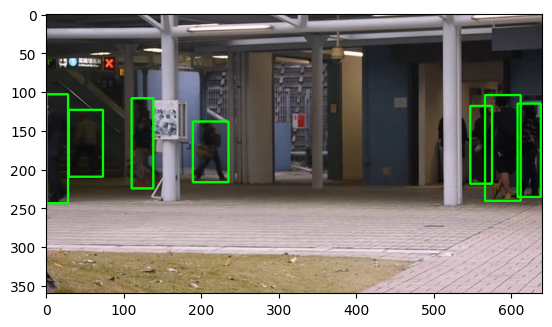

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Load image
image_path = "/content/Avenue_Dataset/images/train/03.avi_frame_119.jpg"  # Change to your frame path
image = cv2.imread(image_path)

# Load labels
# Corrected label_path to point to the .txt file
label_path = "/content/Avenue_Dataset/labels/train/03.avi_frame_119.txt"  # Change to your file path
h, w, _ = image.shape  # Get image dimensions

with open(label_path, "r") as file:
    labels = file.readlines()

for label in labels:
    data = label.split()
    class_id, x, y, bw, bh = map(float, data)

    # Convert normalized YOLO format to pixel values
    x, y, bw, bh = int(x * w), int(y * h), int(bw * w), int(bh * h)
    x1, y1 = x - bw // 2, y - bh // 2
    x2, y2 = x + bw // 2, y + bh // 2

    # Draw bounding box
    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)

# Show image with bounding boxes
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.show()

In [20]:
from google.colab import drive
drive.mount('/content/drive')

NameError: name 'true' is not defined

In [21]:
# Saving the model's best weights after training
model.save("/content/your_model_weights.pt")

In [22]:
import shutil

# Save training run folder
shutil.copytree('/content/runs/detect/train2', '/content/drive/MyDrive/yolo_training_run')


FileExistsError: [Errno 17] File exists: '/content/drive/MyDrive/yolo_training_run'

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
# Load the model from saved weights
model = YOLO("/content/drive/MyDrive/yolo_training_run/weights/best.pt")


In [8]:
!ls /content/drive/MyDrive/


'Colab Notebooks'  'Getting started.pdf'   yolo_training_run


In [23]:
import shutil

# Copy training logs from Drive to Colab
shutil.copytree('/content/drive/MyDrive/yolo_training_run', '/content/runs/detect/train2', dirs_exist_ok=True)


'/content/runs/detect/train2'